# Figure 1 Trained Dataset Stats


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config as c
from violmulti.data.dataset_loader import DatasetLoader
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

%load_ext autoreload
%autoreload 2
sns.set_context("notebook", rc={"font.size": 20, "axes.titlesize": 20, "axes.labelsize": 20, "axes.titleweight": "bold", "xtick.labelsize": 15, "ytick.labelsize": 15})

# Load data
data_loader = DatasetLoader()
data = data_loader.load_new_trained()


# Load Data


In [3]:
df = DatasetLoader().load_data()

DataLoader: Loading data for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']


In [4]:
len(df)

1867005

In [5]:
df.groupby("animal_id").session.nunique().sum()

5251

# B-E Hit Rate, Trial Rate, and Violation Rate


In [6]:
df.head()

,animal_id,session_date,session_file_counter,rig_id,training_stage,s_a,s_b,hit,violation,trial_not_started,...,r_water_vol,antibias_beta,antibias_right_prob,using_psychometric_pairs,choice,session,session_relative_to_old,n_prev_trial_not_started,trial,animal_id_session
0,W051,2014-07-17,327,19,4,60.0,68.0,NaN,1,False,...,18.000000,3,0.5,NaN,2,326,326.0,0.0,1,W051_s326
1,W051,2014-07-17,327,19,4,60.0,68.0,NaN,1,False,...,18.000001,3,0.5,NaN,2,326,326.0,0.0,2,W051_s326
2,W051,2014-07-17,327,19,4,76.0,68.0,NaN,1,False,...,18.000004,3,0.5,NaN,2,326,326.0,0.0,3,W051_s326
3,W051,2014-07-17,327,19,4,68.0,76.0,1.0,0,False,...,18.000014,3,0.5,NaN,0,326,326.0,0.0,4,W051_s326
4,W051,2014-07-17,327,19,4,84.0,76.0,1.0,0,False,...,18.000033,3,0.5,NaN,1,326,326.0,0.0,5,W051_s326


In [7]:
perf_agg_df = df.groupby(["animal_id", "session"]).agg({"hit": "mean", "trial": "max", "violation": "mean"}).reset_index()

In [8]:
def plot_histogram(x, color,df=perf_agg_df, **kwargs):
    fig, ax = plt.subplots(figsize=(6,4))
    sns.despine()

    sns.histplot(x=x, data=df, ax=ax, color=color, element="step", alpha = 0.5,**kwargs)

    median_value = df[x].median()
    ax.axvline(median_value, color=color, linestyle="--", label=f"Median: {median_value:.2f}")

    return fig, ax

## Trial


,index,trial
0,count,5251.000000
1,mean,355.552276
2,std,142.978195
3,min,1.000000
4,25%,262.000000
5,50%,346.000000
6,75%,431.000000
7,max,1494.000000


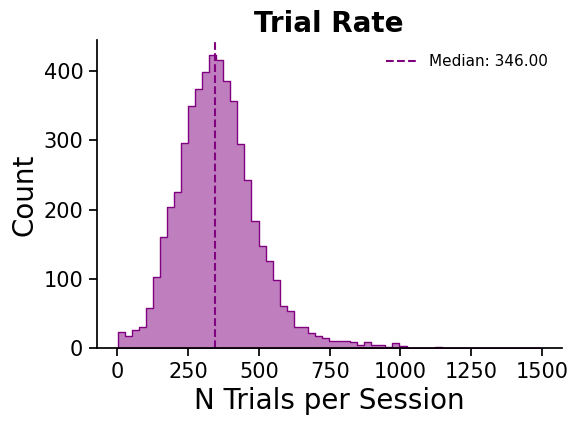

In [9]:
fig, ax = plot_histogram("trial", c.N_TRIAL_COLOR, binwidth=25)
ax.set(xlabel="N Trials per Session")
ax.legend(loc="upper right", frameon=False)
ax.set_title("Trial Rate", fontweight="bold")
fig.savefig("figures/fig1c_trial_rate.png", dpi=300, bbox_inches="tight")
perf_agg_df.trial.describe().reset_index()


## Hit


,index,hit
0,count,5227.000000
1,mean,0.818260
2,std,0.063522
3,min,0.000000
4,25%,0.776632
5,50%,0.814815
6,75%,0.860598
7,max,0.978774


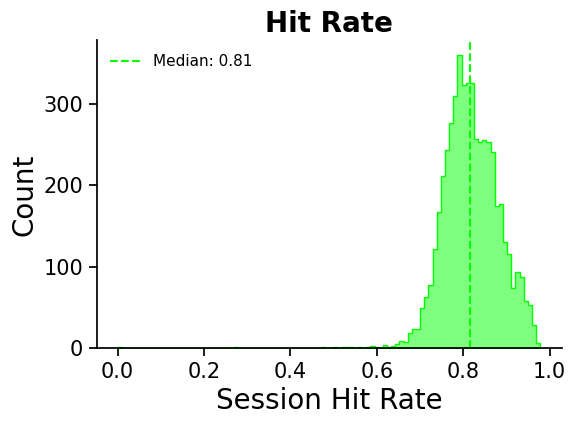

In [11]:
fig, ax = plot_histogram("hit", c.HIT_COLOR)
ax.set(xlabel="Session Hit Rate")
ax.legend(loc="upper left", frameon=False)
ax.set_title("Hit Rate", fontweight="bold")
fig.savefig("figures/fig1d_hit_rate.png", dpi=300, bbox_inches="tight")
perf_agg_df.hit.describe().reset_index()

## Violation


,index,violation
0,count,5251.000000
1,mean,0.178863
2,std,0.108608
3,min,0.013453
4,25%,0.110849
5,50%,0.153226
6,75%,0.216441
7,max,1.000000


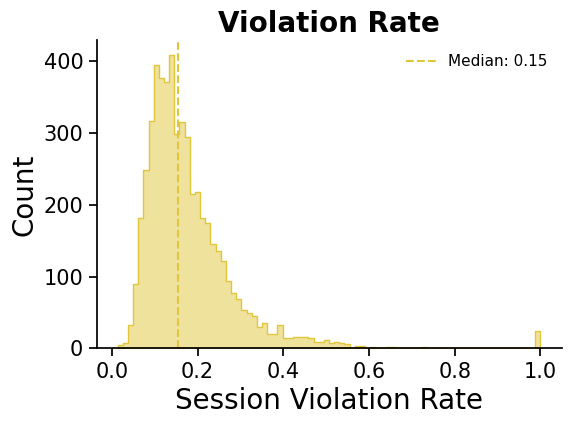

In [76]:
fig, ax = plot_histogram("violation", c.VIOLATION_COLOR)
ax.set(xlabel="Session Violation Rate")
ax.legend(loc="upper right", frameon=False)
ax.set_title("Violation Rate", fontweight="bold")
fig.savefig("figures/fig1e_violation_rate.png", dpi=300, bbox_inches="tight")
perf_agg_df.violation.describe().reset_index()

## Choice Distributions


In [77]:


choice_dist_df = df.groupby(["animal_id", "session"]).choice.value_counts(normalize=True).reset_index()
choice_dist_df["Choice"] = choice_dist_df["choice"].map({0: "Left", 1: "Right", 2: "Violation"})
choice_dist_df["percentage"] = choice_dist_df["proportion"] * 100
choice_dist_df["percentage"] = choice_dist_df["percentage"].round(2)
choice_dist_df.head()
pal= [c.RIGHT_COLOR, c.LEFT_COLOR, c.VIOLATION_COLOR]


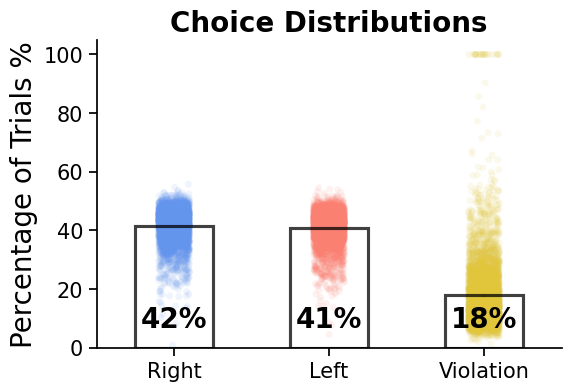

In [78]:

fig, ax = plt.subplots(figsize=(6,4))
sns.despine()

sns.barplot(x="Choice", y="percentage", data=choice_dist_df, ax=ax, width=0.5, fill=False, zorder=10, errorbar="se", color="k", alpha =0.75)
sns.stripplot(x="Choice", y="percentage", data=choice_dist_df, ax=ax, alpha=0.10, palette=pal, hue="Choice")
ax.set(xlabel="", ylabel="Percentage of Trials %")
ax.set_title("Choice Distributions", fontweight="bold")

# Add text labels for each Choice group at y=5
for choice in choice_dist_df["Choice"].unique():
    percentage = choice_dist_df[choice_dist_df["Choice"] == choice]["percentage"].mean()
    ax.text(x=choice, y=5, s=f"{percentage:.0f}%", ha='center', va='bottom', fontweight='bold')

fig.savefig("figures/fig1_choice_percentages.png", dpi=300, bbox_inches="tight")

# F Trained: Violation Rate by Hit Rate


In [79]:
ylim=(0, 0.9)
xlim=(0.5, 1)

/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/1551295419.py:8: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="hit", y="violation", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/1551295419.py:9: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)


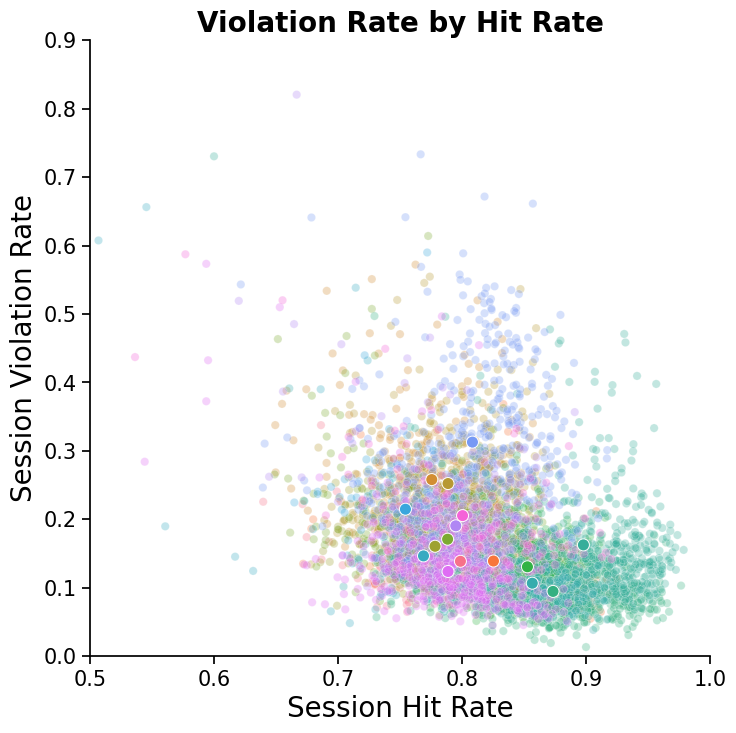

In [80]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

plot_df_all = perf_agg_df.query("trial > 50 and violation < 0.9")
plot_df_by_animal = plot_df_all.groupby("animal_id").agg({"hit": "mean", "violation": "mean", "trial" : "mean"}).reset_index()

sns.scatterplot(x="hit", y="violation", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Session Hit Rate", ylabel="Session Violation Rate", xlim=xlim, ylim=ylim)
ax.set_title("Violation Rate by Hit Rate", fontweight="bold")

ax.get_legend().remove()
fig.savefig("figures/fig1g_violation_rate_by_hit_rate.png", dpi=300, bbox_inches="tight")

In [81]:
# Define the model with animal_id as a grouping (random intercept)
model = smf.mixedlm("violation ~ hit", data=plot_df_all, groups=plot_df_all["animal_id"])

# Fit the model
result = model.fit()

# Print the model summary
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: violation
No. Observations: 5208    Method:             REML     
No. Groups:       16      Scale:              0.0042   
Min. group size:  114     Log-Likelihood:     6808.6960
Max. group size:  552     Converged:          Yes      
Mean group size:  325.5                                
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    0.424    0.021  19.874 0.000  0.383  0.466
hit         -0.307    0.020 -15.402 0.000 -0.346 -0.268
Group Var    0.003    0.018                            



/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


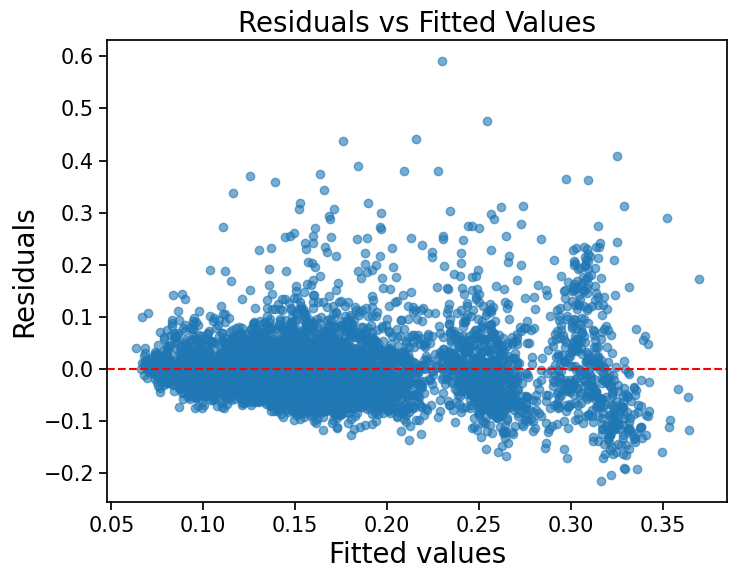

In [82]:
# Extract fitted values and residuals
fitted = result.fittedvalues
residuals = result.resid

plt.figure(figsize=(8, 6))
plt.scatter(fitted, residuals, alpha=0.6)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.axhline(0, color="red", linestyle="--")
plt.show()

In [83]:

# Using the fitted values from the model (includes fixed and random effects)
r2_conditional = r2_score(plot_df_all['violation'], result.fittedvalues)
print("Conditional R-squared:", r2_conditional)

# Extract fixed effect parameters
fixed_intercept = result.fe_params['Intercept']
fixed_slope = result.fe_params['hit']

# Compute predictions using only fixed effects
pred_fixed = fixed_intercept + fixed_slope * plot_df_all['hit']

# Compute marginal R² as the squared correlation between observed values and fixed-effect predictions
r2_marginal = r2_score(plot_df_all['violation'], pred_fixed)
print("Marginal R-squared:", r2_marginal)

Conditional R-squared: 0.49505702840215526
Marginal R-squared: 0.08602465336050635


In [84]:
import statsmodels.api as sm
import pandas as pd

# Add a constant (intercept term) to the model
X = sm.add_constant(plot_df_by_animal[['hit']])
y = plot_df_by_animal['violation']

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              violation   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     3.334
Date:                Thu, 24 Apr 2025   Prob (F-statistic):             0.0893
Time:                        15:27:28   Log-Likelihood:                 24.521
No. Observations:                  16   AIC:                            -45.04
Df Residuals:                      14   BIC:                            -43.50
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7002      0.288      2.434      0.0

/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)


In [85]:

# Fit a simple linear regression model
model = LinearRegression()
X = plot_df_by_animal[['hit']]
y = plot_df_by_animal['violation']
model.fit(X, y)

# Generate predictions and compute R-squared
y_pred = model.predict(X)
r2_aggregated = r2_score(y, y_pred)
print("R-squared on aggregated data:", r2_aggregated)
print(f"Slope: {model.coef_[0]}, Intercept: {model.intercept_}")

R-squared on aggregated data: 0.1923188498254904
Slope: -0.6481507438786582, Intercept: 0.7002394892449354


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/3555912220.py:5: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


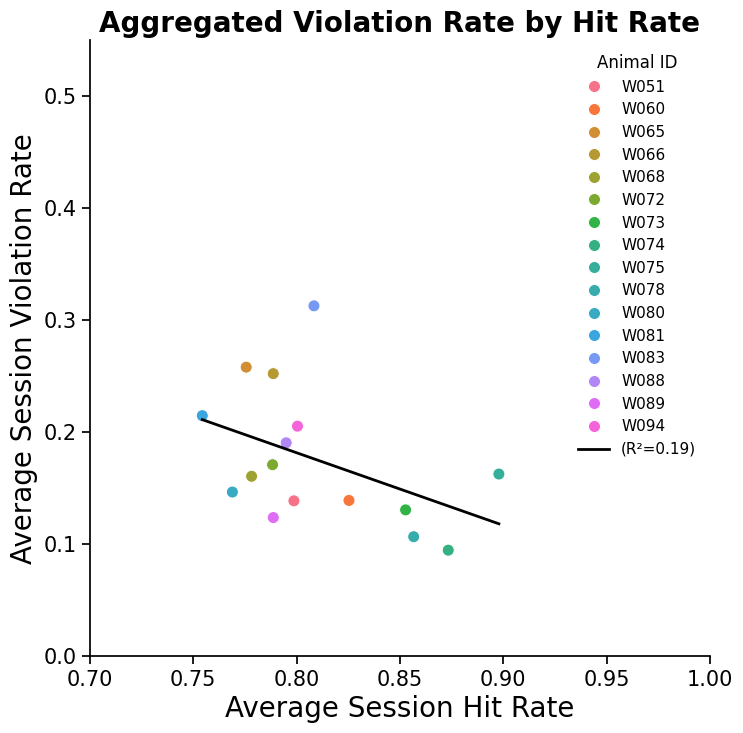

In [86]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Average Session Hit Rate", ylabel="Average Session Violation Rate")
ax.set_title("Aggregated Violation Rate by Hit Rate", fontweight="bold")

# Plot the linear regression line in black
# Create x-values spanning the range of hit rates
x_vals = np.linspace(plot_df_by_animal['hit'].min(), plot_df_by_animal['hit'].max(), 100)
# Predict violation rates using the regression model
y_vals = model.predict(x_vals.reshape(-1, 1))
# Plot the regression line
ax.plot(x_vals, y_vals, color='black', linewidth=2, label=f"(R²={r2_aggregated:.2f})")

# Update the legend to include the regression line
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title="Animal ID", frameon=False, loc="upper right")


ax.set(xlim=(0.7, 1), ylim=(0, 0.55))
fig.savefig("figures/fig1f_violation_rate_by_hit_rate_by_animal.png", dpi=300, bbox_inches="tight")

---

# EXTRA: Learning: Violation Rate by Hit Rate


In [27]:
ldf = DatasetLoader(data_type="new_all").load_data()


DataLoader: Loading data for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']


In [28]:
# Merge ldf with train_time_df to get the train_time for each animal
ldf_merged = ldf.merge(train_time_df, on='animal_id')
# Group by animal_id and filter each group based on train_time
ldf_filt = ldf_merged.query("training_stage >= 3").groupby('animal_id').apply(
    lambda group: group[group['session_file_counter'] < group['train_time'].iloc[0]]
).reset_index(drop=True)

ldf_filt.head()

/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/536801089.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ldf_filt = ldf_merged.query("training_stage >= 3").groupby('animal_id').apply(


,animal_id,session_date,session_file_counter,rig_id,training_stage,s_a,s_b,hit,violation,trial_not_started,...,r_water_vol,antibias_beta,antibias_right_prob,using_psychometric_pairs,choice,session,session_relative_to_old,n_prev_trial_not_started,trial,train_time
0,W051,2013-08-15,30,2,3,68.0,60.0,NaN,1,False,...,18.000000,2,0.5,NaN,2,30,30.0,0.0,1,326
1,W051,2013-08-15,30,2,3,68.0,76.0,NaN,1,False,...,18.000001,2,0.5,NaN,2,30,30.0,0.0,2,326
2,W051,2013-08-15,30,2,3,68.0,60.0,NaN,1,False,...,18.000004,2,0.5,NaN,2,30,30.0,0.0,3,326
3,W051,2013-08-15,30,2,3,68.0,76.0,NaN,1,False,...,18.000014,2,0.5,NaN,2,30,30.0,0.0,4,326
4,W051,2013-08-15,30,2,3,76.0,68.0,NaN,1,False,...,18.000033,2,0.5,NaN,2,30,30.0,0.0,5,326


In [29]:
perf_agg_ldf = ldf_filt.groupby(["animal_id", "session"]).agg({"hit": "mean", "trial": "max", "violation": "mean"}).reset_index()
xlim=(0.1, 1)
ylim=(0, 0.9)

/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/843444691.py:8: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="hit", y="violation", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/843444691.py:9: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)


[(0.1, 1.0), (0.0, 0.9)]

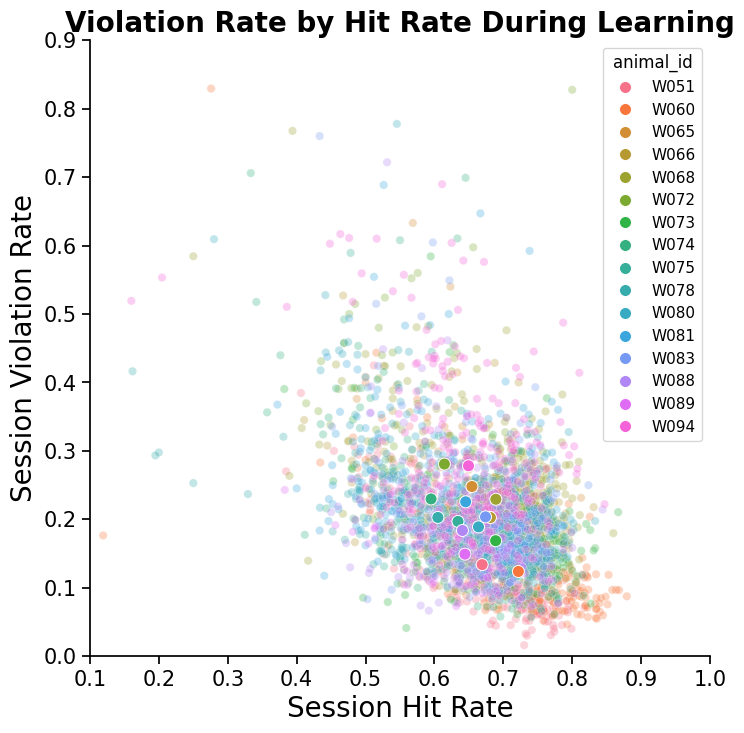

In [30]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

plot_df_all = perf_agg_ldf.query("trial > 50 and violation < 0.9")
plot_df_by_animal = plot_df_all.groupby("animal_id").agg({"hit": "mean", "violation": "mean", "trial" : "mean"}).reset_index()

sns.scatterplot(x="hit", y="violation", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Session Hit Rate", ylabel="Session Violation Rate")
ax.set_title("Violation Rate by Hit Rate During Learning", fontweight="bold")
ax.set(xlim=xlim, ylim=ylim)

# ax.legend(title="Animal ID", frameon=False)
# fig.savefig("figures/fig1g_learning_violation_rate_by_hit_rate.png", dpi=300, bbox_inches="tight")

In [31]:
# Define the model with animal_id as a grouping (random intercept)
model = smf.mixedlm("violation ~ hit", data=plot_df_all, groups=plot_df_all["animal_id"])

# Fit the model
result = model.fit()

# Print the model summary
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: violation
No. Observations: 3174    Method:             REML     
No. Groups:       16      Scale:              0.0058   
Min. group size:  73      Log-Likelihood:     3619.6473
Max. group size:  438     Converged:          Yes      
Mean group size:  198.4                                
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    0.473    0.014  32.820 0.000  0.445  0.501
hit         -0.413    0.016 -26.613 0.000 -0.443 -0.382
Group Var    0.002    0.008                            



/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [32]:
# Using the fitted values from the model (includes fixed and random effects)
r2_conditional = r2_score(plot_df_all['violation'], result.fittedvalues)
print("Conditional R-squared:", r2_conditional)

# Extract fixed effect parameters
fixed_intercept = result.fe_params['Intercept']
fixed_slope = result.fe_params['hit']

# Compute predictions using only fixed effects
pred_fixed = fixed_intercept + fixed_slope * plot_df_all['hit']

# Compute marginal R² as the squared correlation between observed values and fixed-effect predictions
r2_marginal = r2_score(plot_df_all['violation'], pred_fixed)
print("Marginal R-squared:", r2_marginal)

Conditional R-squared: 0.35910071939215515
Marginal R-squared: 0.17944668802813113


In [33]:
model = LinearRegression()
X = plot_df_by_animal[['hit']]
y = plot_df_by_animal['violation']
model.fit(X, y)

# Generate predictions and compute R-squared
y_pred = model.predict(X)
r2_aggregated = r2_score(y, y_pred)
print("R-squared on aggregated data:", r2_aggregated)

R-squared on aggregated data: 0.2341435957725534


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/389157016.py:5: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


[(0.5, 0.8), (0.0, 0.5)]

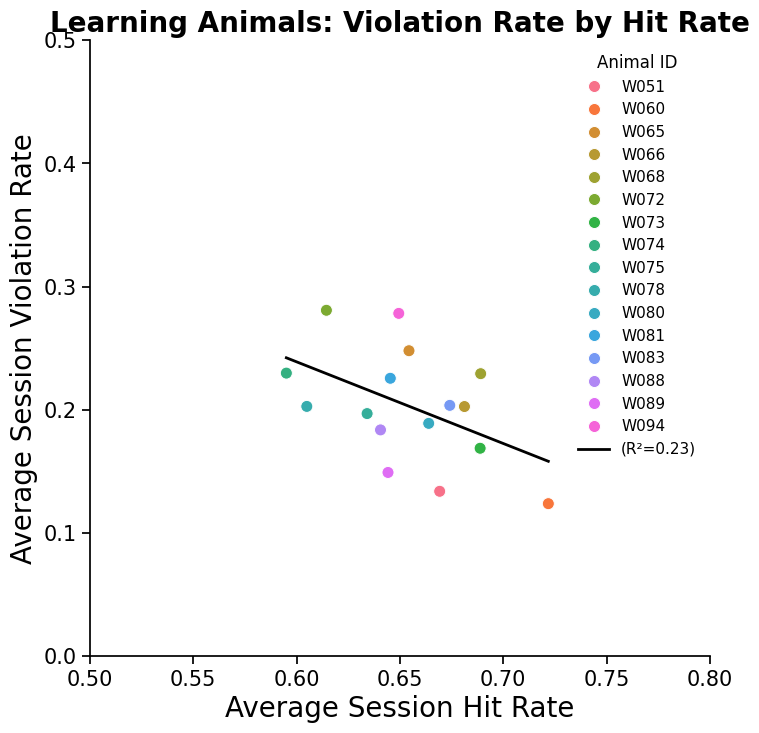

In [34]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Average Session Hit Rate", ylabel="Average Session Violation Rate")
ax.set_title("Learning Animals: Violation Rate by Hit Rate", fontweight="bold")

# Plot the linear regression line in black
# Create x-values spanning the range of hit rates
x_vals = np.linspace(plot_df_by_animal['hit'].min(), plot_df_by_animal['hit'].max(), 100)
# Predict violation rates using the regression model
y_vals = model.predict(x_vals.reshape(-1, 1))
# Plot the regression line
ax.plot(x_vals, y_vals, color='black', linewidth=2, label=f"(R²={r2_aggregated:.2f})")

# Update the legend to include the regression line
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title="Animal ID", frameon=False, loc="upper right")

# fig.savefig("figures/fig1g_learning_violation_rate_by_hit_rate_by_animal.png", dpi=300, bbox_inches="tight")
ax.set(xlim=(0.5, 0.8), ylim=(0, 0.5))

# EXTRA- Time to Train


In [ ]:
train_time_df = df.groupby(["animal_id"]).session.min().reset_index().rename(columns={"session": "train_time"})
train_time_df.head() 

,animal_id,train_time
0,W051,326
1,W060,248
2,W065,101
3,W066,286
4,W068,423


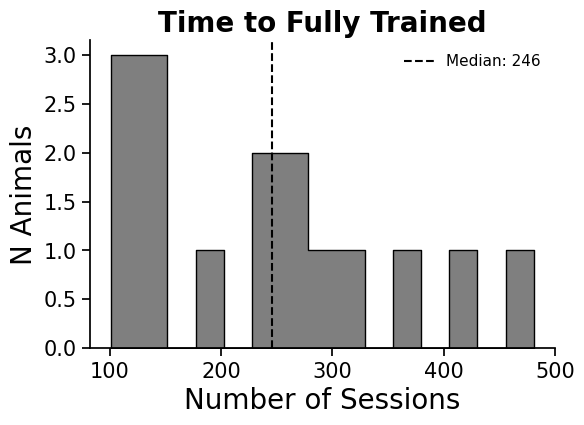

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.despine()

sns.histplot(x="train_time", data=train_time_df, ax=ax, element="step", color="k", binwidth=25, alpha=0.5)

ax.set(xlabel="Number of Sessions", ylabel="N Animals")
ax.set_title("Time to Fully Trained", fontweight="bold")

median_value = train_time_df.train_time.median()
ax.axvline(median_value, color="k", linestyle="--", label=f"Median: {median_value:.0f}")
ax.legend(loc="upper right", frameon=False)

fig.savefig("figures/fig1b_time_to_train_hist.png", dpi=300, bbox_inches="tight")




# EXTRA: Violation Rate by Time


In [35]:
ldf_filt = ldf_merged.query("training_stage >=3").copy()
ldf_filt["session_relative_to_trained"] = ldf_filt["session"] - ldf_filt["train_time"]
ldf_filt.head()

perf_agg_ldf = ldf_filt.groupby(["animal_id", "session_relative_to_trained"]).agg({"hit": "mean", "trial": "max", "violation": "mean"}).reset_index()

In [36]:
perf_agg_ldf.head()

,animal_id,session_relative_to_trained,hit,trial,violation
0,W051,-296,0.512077,360,0.425000
1,W051,-295,0.505208,271,0.291513
2,W051,-294,0.384615,285,0.270175
3,W051,-293,0.490323,210,0.261905
4,W051,-292,0.454082,280,0.300000


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/4193738791.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(sub["hit"], sub["violation"])
/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/4193738791.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cdf


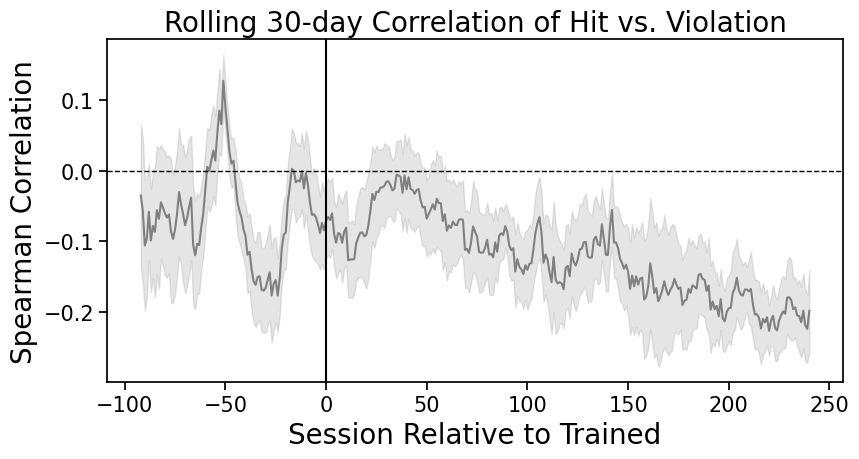

In [37]:
from scipy.stats import spearmanr
cdf = (
    perf_agg_ldf
    .groupby(["animal_id", "session_relative_to_trained"])
    .agg({"hit": "mean", "violation": "mean"})
    .reset_index()
    .sort_values(["animal_id", "session_relative_to_trained"])
)

def compute_rolling_spearman(df, window=30):
    df = df.sort_values("session_relative_to_trained").copy()
    corrs = []
    
    # Loop over sliding window
    for i in range(len(df)):
        if i < window - 1:
            corrs.append(np.nan)
        else:
            sub = df.iloc[i - window + 1:i + 1]
            r, _ = spearmanr(sub["hit"], sub["violation"])
            corrs.append(r)
    
    df["rolling_spearman"] = corrs
    return df
cdf_spearman = (
    cdf
    .groupby("animal_id", group_keys=True)
    .apply(compute_rolling_spearman, window=30)
    .reset_index(drop=True)
)

# Count participation per session
animal_counts = (
    cdf_spearman
    .groupby("session_relative_to_trained")["animal_id"]
    .nunique()
    .reset_index(name="n_animals")
)

# Merge + filter
cdf_spearman = cdf_spearman.merge(animal_counts, on="session_relative_to_trained")
cdf_spearman = cdf_spearman[cdf_spearman["n_animals"] >= 13]

fig, ax = plt.subplots(figsize=(9,5))
sns.lineplot(
    data=cdf_spearman,
    x="session_relative_to_trained",
    y="rolling_spearman",
    estimator="mean",
    errorbar="se",
    n_boot=1000,
    color="gray"
)
ax.axhline(0, color="k", linestyle="--", linewidth=1)
ax.set_title("Rolling 30-day Correlation of Hit vs. Violation")
ax.set_xlabel("Session Relative to Trained")
ax.set_ylabel("Spearman Correlation")

ax.axvline(x=0, color="k", linestyle="-", linewidth=1.5)
plt.tight_layout()
plt.show()

#save fig
# fig.savefig("figures/fig1h_viol_hit_correlation_over_time.png", dpi=300, bbox_inches="tight")


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/1524230318.py:8: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="hit", y="violation", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/1524230318.py:9: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)


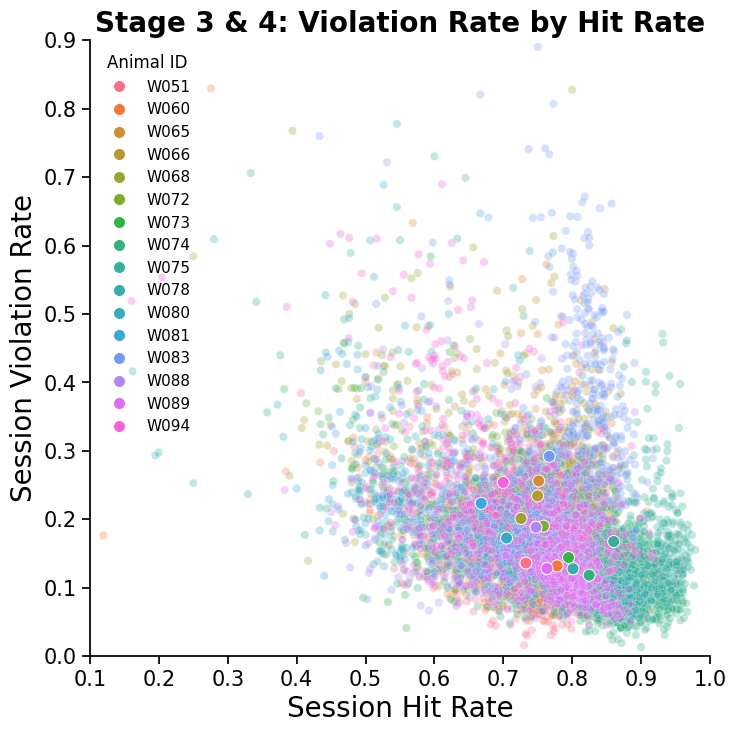

In [38]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

plot_df_all = perf_agg_ldf.query("trial > 50 and violation < 0.9")
plot_df_by_animal = plot_df_all.groupby("animal_id").agg({"hit": "mean", "violation": "mean", "trial" : "mean"}).reset_index()

sns.scatterplot(x="hit", y="violation", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Session Hit Rate", ylabel="Session Violation Rate", xlim=xlim, ylim=ylim)
ax.set_title("Stage 3 & 4: Violation Rate by Hit Rate", fontweight="bold")

ax.legend(title="Animal ID", frameon=False)
# fig.savefig("figures/fig1h_violation_rate_by_hit_rate.png", dpi=300, bbox_inches="tight")

In [39]:
# Define the model with animal_id as a grouping (random intercept)
model = smf.mixedlm("violation ~ hit", data=plot_df_all, groups=plot_df_all["animal_id"])

# Fit the model
result = model.fit()

# Print the model summary
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: violation
No. Observations: 8423    Method:             REML     
No. Groups:       16      Scale:              0.0060   
Min. group size:  331     Log-Likelihood:     9550.0118
Max. group size:  698     Converged:          Yes      
Mean group size:  526.4                                
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    0.389    0.014  27.605 0.000  0.362  0.417
hit         -0.269    0.009 -30.155 0.000 -0.286 -0.251
Group Var    0.002    0.012                            



/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [40]:

# Using the fitted values from the model (includes fixed and random effects)
r2_conditional = r2_score(plot_df_all['violation'], result.fittedvalues)
print("Conditional R-squared:", r2_conditional)

# Extract fixed effect parameters
fixed_intercept = result.fe_params['Intercept']
fixed_slope = result.fe_params['hit']

# Compute predictions using only fixed effects
pred_fixed = fixed_intercept + fixed_slope * plot_df_all['hit']

# Compute marginal R² as the squared correlation between observed values and fixed-effect predictions
r2_marginal = r2_score(plot_df_all['violation'], pred_fixed)
print("Marginal R-squared:", r2_marginal)

Conditional R-squared: 0.36731230939551374
Marginal R-squared: 0.11273811265050815


In [41]:
# Fit a simple linear regression model
model = LinearRegression()
X = plot_df_by_animal[['hit']]
y = plot_df_by_animal['violation']
model.fit(X, y)

# Generate predictions and compute R-squared
y_pred = model.predict(X)
r2_aggregated = r2_score(y, y_pred)
print("R-squared on aggregated data:", r2_aggregated)

R-squared on aggregated data: 0.20441389346204442


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/1083036259.py:5: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


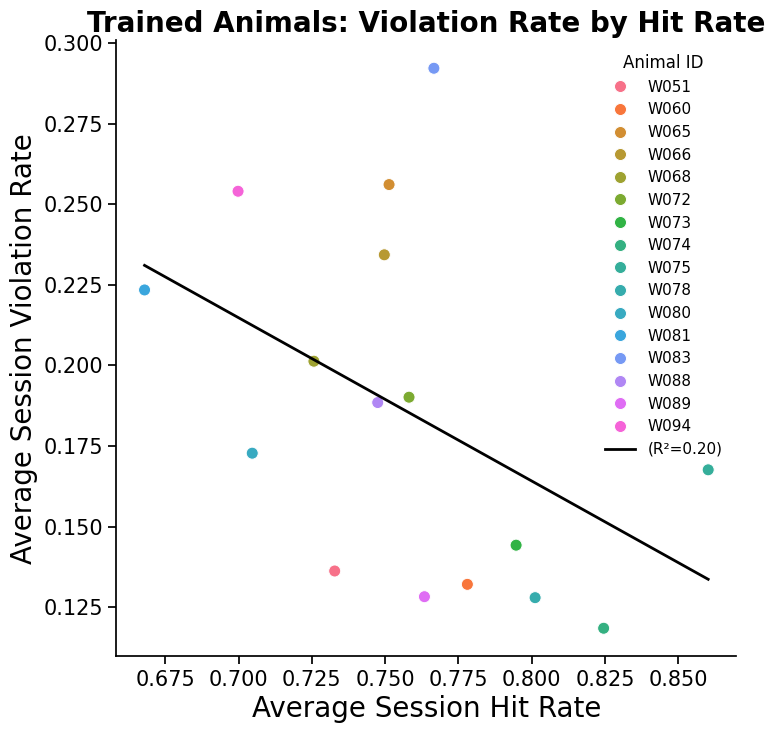

In [42]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Average Session Hit Rate", ylabel="Average Session Violation Rate")
ax.set_title("Trained Animals: Violation Rate by Hit Rate", fontweight="bold")

# Plot the linear regression line in black
# Create x-values spanning the range of hit rates
x_vals = np.linspace(plot_df_by_animal['hit'].min(), plot_df_by_animal['hit'].max(), 100)
# Predict violation rates using the regression model
y_vals = model.predict(x_vals.reshape(-1, 1))
# Plot the regression line
ax.plot(x_vals, y_vals, color='black', linewidth=2, label=f"(R²={r2_aggregated:.2f})")

# Update the legend to include the regression line
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title="Animal ID", frameon=False, loc="upper right")


# fig.savefig("figures/fig1fh_stage34_violation_rate_by_hit_rate_by_animal.png", dpi=300, bbox_inches="tight")
# ax.set(xlim=(0.7, 1), ylim=(0, 0.55))

# Extra: Choice Distributions


---

# EXTRA: Violation Rate by N Trials


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/137002731.py:5: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="trial", y="violation", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/137002731.py:6: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="trial", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)


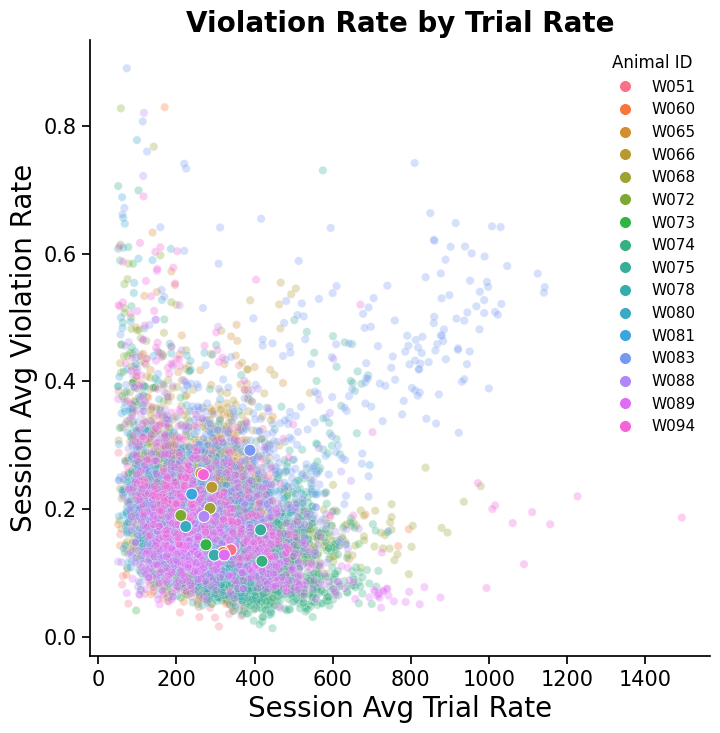

In [44]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

sns.scatterplot(x="trial", y="violation", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
sns.scatterplot(x="trial", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Session Avg Trial Rate", ylabel="Session Avg Violation Rate")
ax.set_title("Violation Rate by Trial Rate", fontweight="bold")

ax.legend(title="Animal ID", frameon=False)
# fig.savefig("figures/fig1e_violation_rate_by_trial_rate.png", dpi=300, bbox_inches="tight")

In [45]:
# Define the model with animal_id as a grouping (random intercept)
model = smf.mixedlm("violation ~ trial", data=plot_df_all, groups=plot_df_all["animal_id"])

# Fit the model
result = model.fit()

# Print the model summary
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: violation
No. Observations: 8423    Method:             REML     
No. Groups:       16      Scale:              0.0066   
Min. group size:  331     Log-Likelihood:     9141.4369
Max. group size:  698     Converged:          Yes      
Mean group size:  526.4                                
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.201    0.013 14.923 0.000  0.175  0.228
trial        -0.000    0.000 -7.818 0.000 -0.000 -0.000
Group Var     0.003    0.013                           



/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_5830/806912244.py:5: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="trial", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)


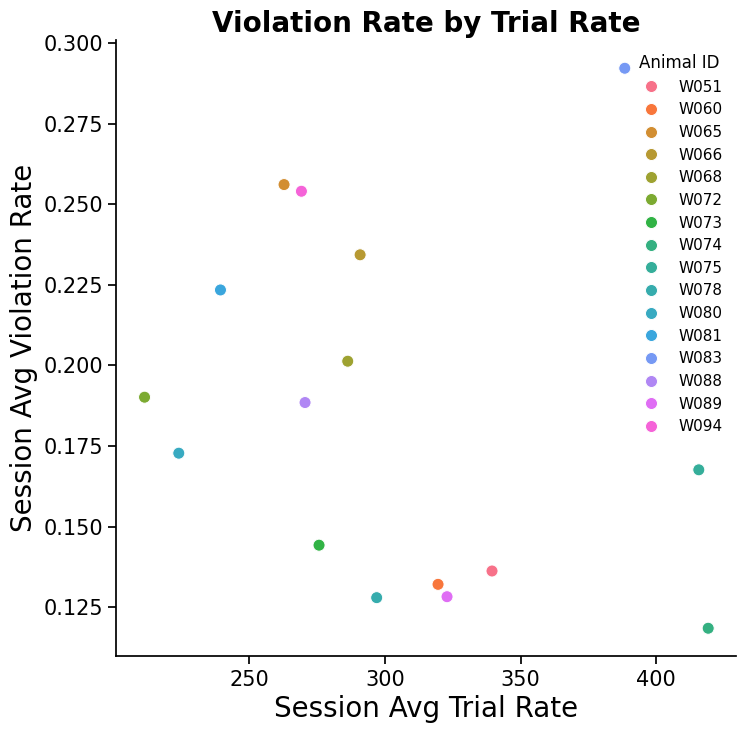

In [46]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

sns.scatterplot(x="trial", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Session Avg Trial Rate", ylabel="Session Avg Violation Rate")
ax.set_title("Violation Rate by Trial Rate", fontweight="bold")

ax.legend(title="Animal ID", frameon=False, loc="upper right")
# fig.savefig("figures/fig1e_violation_rate_by_hit_rate.png", dpi=300, bbox_inches="tight")
# ax.set(xlim=(0.7, 1), ylim=(0, 0.55))

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# Fit a simple linear regression model
model = LinearRegression()
X = plot_df_by_animal[['trial']]
y = plot_df_by_animal['violation']
model.fit(X, y)

# Generate predictions and compute R-squared
y_pred = model.predict(X)
r2_aggregated = r2_score(y, y_pred)
print("R-squared on aggregated data:", r2_aggregated)

R-squared on aggregated data: 0.0465854531829798


Text(0.5, 1.0, 'Violation Rate by Trial Rate')

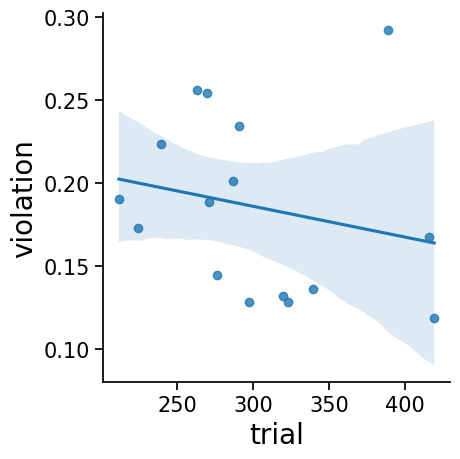

In [48]:
sns.lmplot(x="trial", y="violation", data=plot_df_by_animal)
ax.set(xlabel="Session Avg Trial Rate", ylabel="Session Avg Violation Rate")
ax.set_title("Violation Rate by Trial Rate", fontweight="bold")
